## Markov Chain Montecarlo (MCMC)
In this exercise, we have measured the flux of a time-dependent astrophysical event, and we aim to model the time evolution of the observed flux.
A plausible model for this behavior is:
$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $y$ is the flux, $t$ is time, $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst decays.
To estimate the posterior distribution of the model parameters, we apply a Markov Chain Monte Carlo (MCMC) approach using the emcee sampler. This involve defining the likelihood of the model and the priors on the parameters:
$b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$.



In [106]:
import numpy as np
from matplotlib import pyplot as plt
path = 'C:/Users/alexv/Desktop/Università/astrostat/astrostatistics_bicocca_2025/solutions/transient.npy'
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy


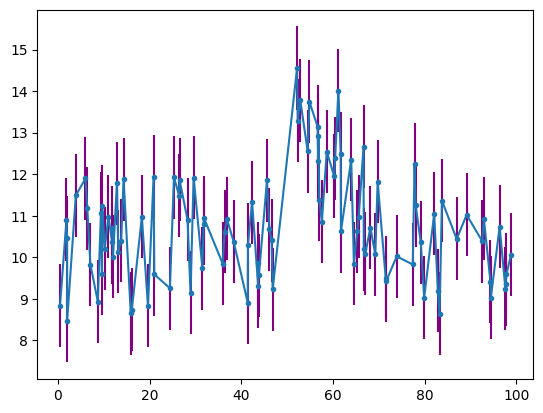

In [107]:
#Plotting the data
data = np.load(path)
time = data[:,0]
flux = data[:,1]
err = data[:,2]
plt.errorbar(time, flux, yerr = err, ecolor = 'purple', marker = '.')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()


In [108]:
def model(t, alfa, a, b, t0):
    temp = np.where(t < t0, b, b + a * np.exp(-alfa * (t - t0)))
    return temp

In [109]:
!pip install emcee

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\alexv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [110]:
# Defining Likelihood and prior 
"""
def likelihood(theta, t,y, sigma):
    a, b, alfa, t0 = theta
    model_vals = model(t, alfa, a, b, t0)
    return np.prod(np.exp(-0.5*(y - model_vals) / sigma) ** 2)
"""
# emcee wants ln of posterior pdf

def log_prior(theta):
    a, b, alfa, t0 = theta
    if (0 < a < 50) and (0 < b < 50) and (0 < t0 < 100) and (np.exp(-5) < alfa < np.exp(5)):
        return -np.log(alfa)  # log-uniform for alfa; the other parameters give constants which are ignored in the emcee algorithm
    else:
        return -np.inf
        #if sampler goes out of bound returns -infi therefore - infi posterior, walker goes away from that parameter region
    
"""
def likelihood(theta, t,y, sigma):
    a, b, alfa, t0 = theta
    model_vals = model(t, alfa, a, b, t0)
    return np.prod(np.exp(-0.5*(y - model_vals) / sigma) ** 2)
"""    
def log_likelihood(theta, t, y, sigma):
    a, b, alfa, t0 = theta
    model_vals = model(t, alfa, a, b, t0)
    return -0.5 * np.sum(((y - model_vals) / sigma) ** 2)

def log_posterior(theta, t, y, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, sigma)
import emcee

In [111]:
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\alexv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [119]:
b  = 10
a = 10
t0 = 15
alfa = np.log(10)

ndim = 4  # number of parameters in the model
nwalkers = 10  # at least 2×ndim walkers
burn = 10000  # "burn-in" period to let chains stabilize
nsteps = 100000  # number of MCMC steps to take for each walker

# initialize theta 
np.random.seed(0)
initial = [5, 10, 1 , 50]  # a, b, alfa, t0
starting_guesses = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[time, flux, err])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)

# sampler.chain shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print(sampler.chain.shape) #original chain structure 

print(emcee_trace.shape) #burned and flattened chain
print("done")

C:\Users\alexv\AppData\Local\Temp\ipykernel_15692\2802320889.py:2: RuntimeWarning: overflow encountered in exp
  temp = np.where(t < t0, b, b + a * np.exp(-alfa * (t - t0)))
C:\Users\alexv\AppData\Local\Temp\ipykernel_15692\2802320889.py:2: RuntimeWarning: overflow encountered in multiply
  temp = np.where(t < t0, b, b + a * np.exp(-alfa * (t - t0)))
100%|██████████| 100000/100000 [00:56<00:00, 1779.29it/s]

(10, 100000, 4)
(900000, 4)
done


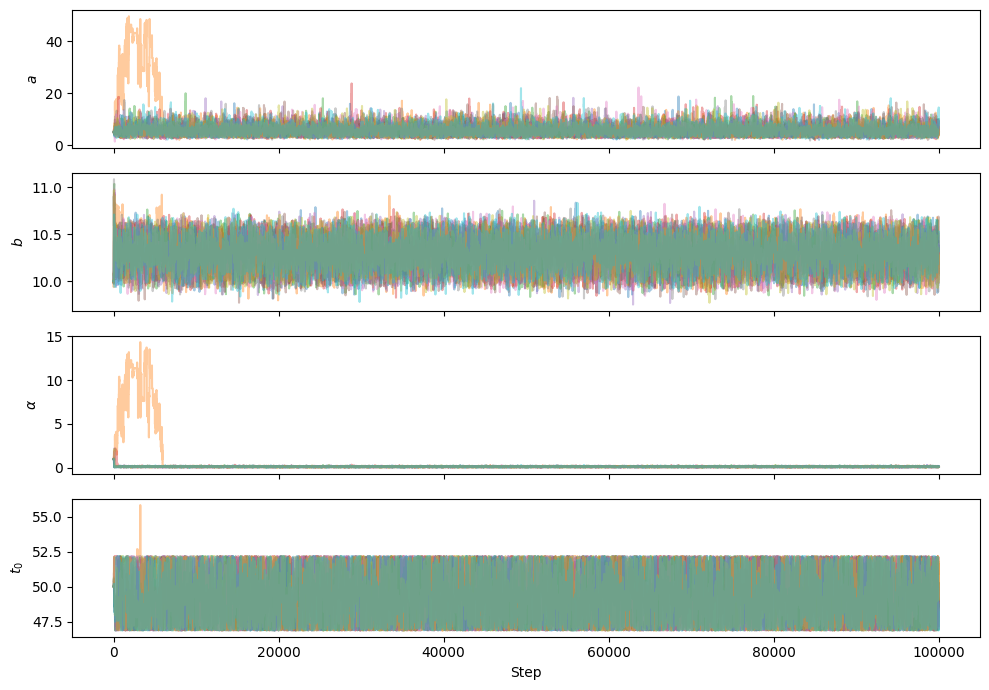

In [120]:
labels = [r"$a$", r"$b$", r"$\alpha$", r"$t_{0}$"]
chains = sampler.get_chain()  # shape: (nsteps, nwalkers, ndim)
nsteps, nwalkers, ndim = chains.shape

fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)

steps = np.arange(nsteps)
#trace plots of original chain for various parameters
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(steps, chains[:, walker, i], alpha=0.4)
    ax.set_ylabel(labels[i])


axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

In [132]:
#get autocorrelation time bewtween points
tau = sampler.get_autocorr_time(tol = 0)
print(tau)
burning = 12*int(np.max(tau))
print(burning)
chains_burn = sampler.get_chain(discard = burning, flat = False)
thin = int(np.max(tau))

#trace thinned and flattened
flat_trace = sampler.get_chain(discard = burning, thin=thin, flat=True) 
print("shape flattend", flat_trace.shape)

[364.75312851  87.51954304 481.9316074  106.19936559]
5772
shape flattend (1950, 4)


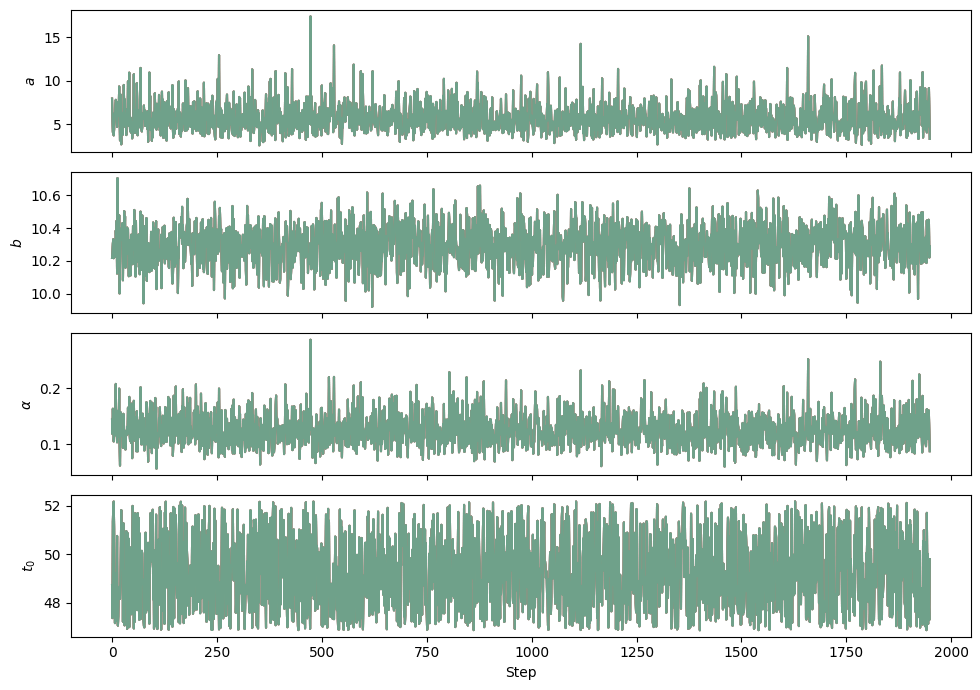

In [133]:

fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)

steps = np.arange(len(flat_trace))
#trace plots of thinned and burned chain for various parameters
for i in range(ndim):
    ax = axes[i]
    for walker in range(nwalkers):
        ax.plot(steps, flat_trace[:, i], alpha=0.4)
    ax.set_ylabel(labels[i])


axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

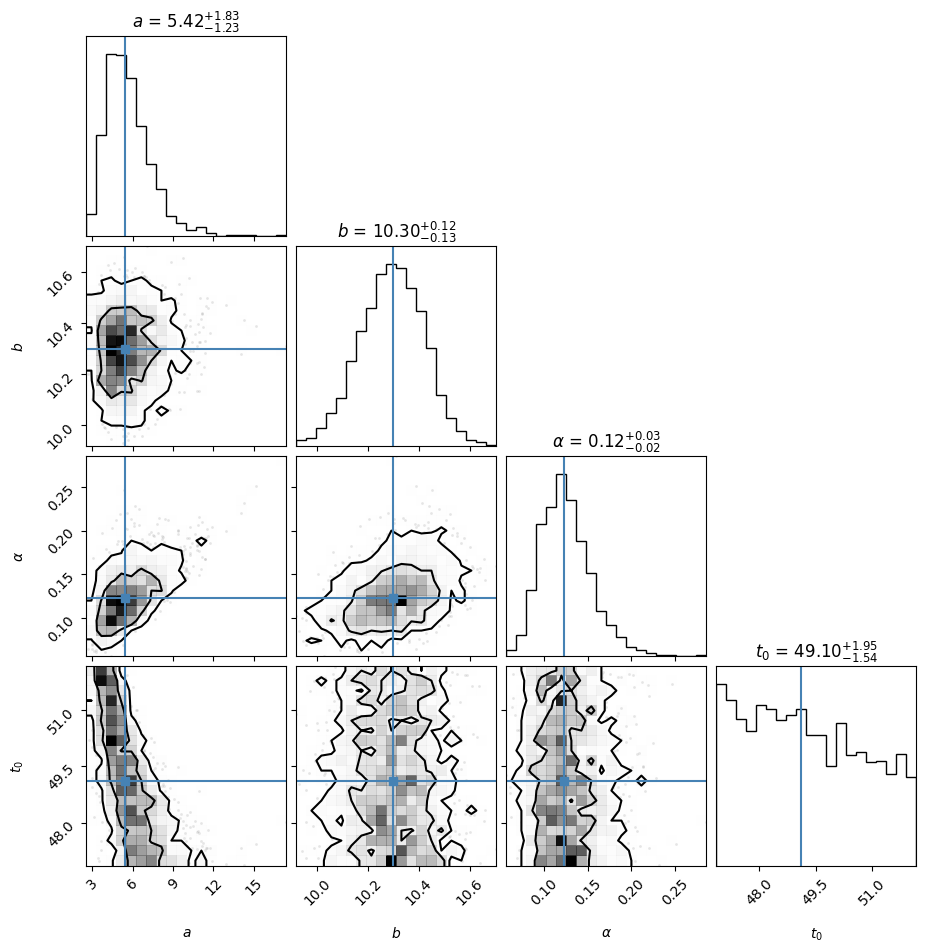

In [139]:
import corner
a_median = np.median(flat_trace[:, 0])
b_median = np.median(flat_trace[:,1])
alfa_median = np.median(flat_trace[:, 2])
t0_median = np.median(flat_trace[:,3])
#Corner plot with 68% and 95 % countours
fig = corner.corner(flat_trace, labels = labels, levels = [0.68, 0.95], show_title = True, truths = [a_median, b_median, alfa_median, t0_median], show_titles = True, title_kwargs = {'fontsize':12})




There is a  mild negative correlation between $a$ ,amplitude of the pulse, and $t_{0}$. Similarly, $a$ and $\alpha$ are correleted positevely, as $a$ grows the decay time of the flux is longer.

(100, 4)


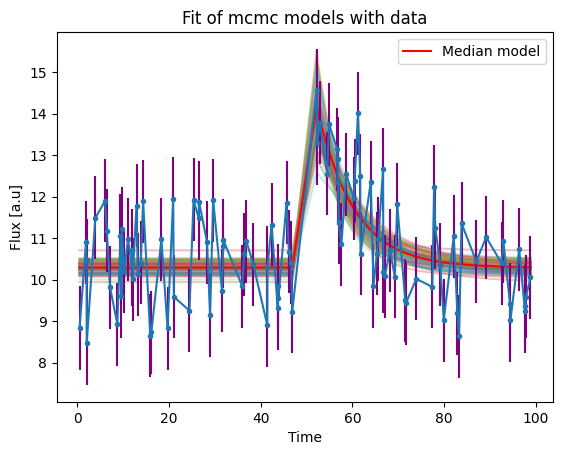

Median value of a 5.4152030791301256 +- 2.0204633443272835
Median value of b 10.299690389117494 +- 0.16997506816303698
Median value of alfa 0.12274845340666488 +- 0.03726819140530234
Median value of t0 49.10126028984856 +- 2.482658351188711


In [135]:

median = []
model_arr = []

for i in range(4):
    median.append(np.median(flat_trace[:,i])) #take the median for each parameter 

#Plot the various model with the parameters of the chain
for i in range(len(sample_para)):
    a_i, b_i, alfa_i, t0_i = flat_trace[i,:]
    model_arr.append(model(time, alfa_i, a_i, b_i, t0_i))
    plt.plot(time, model_arr[i], alpha = 0.3)
    
#Model with the median of the parameters
model_median = model(time, median[2], median[0], median[1], median[3])
plt.plot(time, model_median, color = 'red', linestyle = '-', label = 'Median model')
plt.legend()
plt.errorbar(time, flux, yerr = err, marker = '.', ecolor = 'purple')
plt.title("Fit of mcmc models with data")
plt.xlabel("Time")
plt.ylabel("Flux [a.u]")
plt.show()

#Interquantile range
a_iqr = scipy.stats.iqr(flat_trace[:, 0], rng = (25,75))
b_iqr = scipy.stats.iqr(flat_trace[:, 1], rng = (25,75))
alfa_iqr = scipy.stats.iqr(flat_trace[:, 2], rng = (25,75))
t0_iqr = scipy.stats.iqr(flat_trace[:, 3], rng = (25,75))
print(f'Median value of a {a_median} +- {a_iqr}')
print(f'Median value of b {b_median} +- {b_iqr}')
print(f'Median value of alfa {alfa_median} +- {alfa_iqr}')
print(f'Median value of t0 {t0_median} +- {t0_iqr}')
#Posterior of model extract modelspread of model indicative of error. instead of one line, ML, ho posterior model la cui ditrib ha dai idea

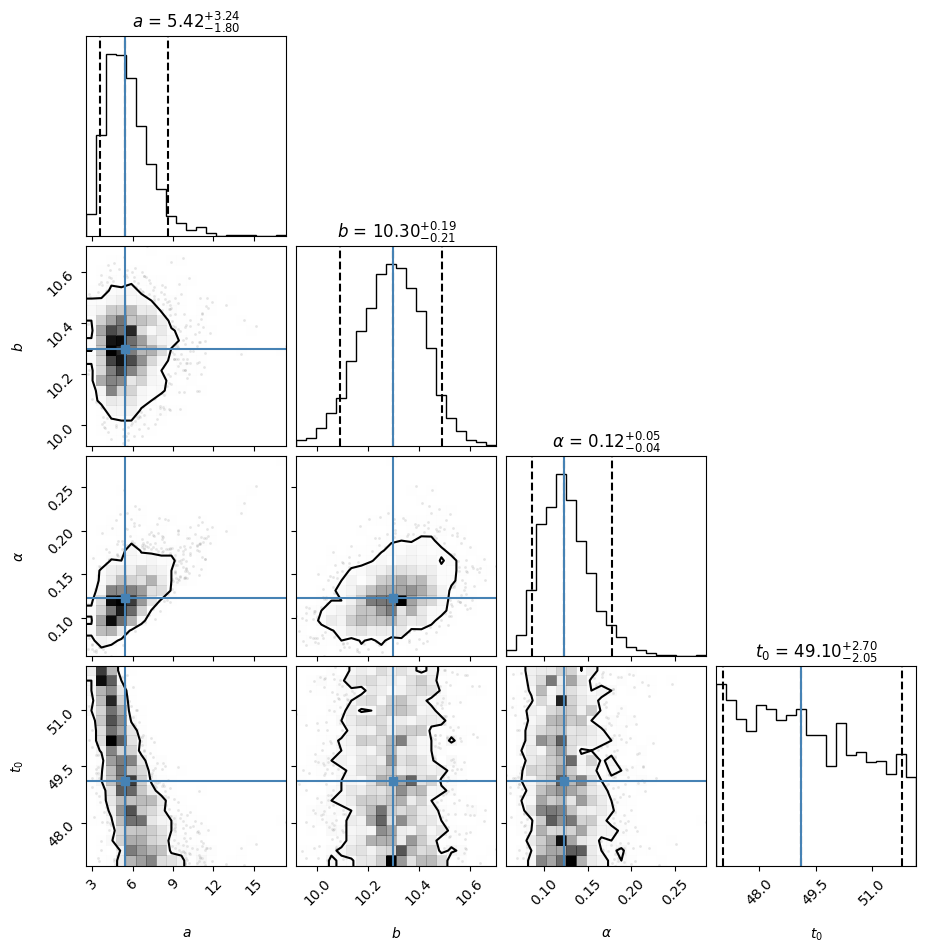

In [140]:
#Corner plot with 90% countour and 5%, 50% and 95% percentile plotted as vertical lines
fig = corner.corner(flat_trace, labels = labels, levels = [0.9], truths = [a_median, b_median, alfa_median, t0_median], quantiles = [0.05, 0.5, 0.95], show_titles = True, title_kwargs = {'fontsize':12})
